In [1]:
import anndata as a
import pandas as pd
import scanpy as sc
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

In [2]:
mpl.rcParams["figure.figsize"] = (5, 5)
mpl.rcParams['pdf.fonttype'] = 42

In [3]:
adata = sc.read('/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/ascites_case/ascites_malignant_cells_primary_and_first_timepoint.h5ad')
adata

AnnData object with n_obs × n_vars = 2478 × 17005
    obs: 'orig.ident', 'nCount_RNA', 'RNA_snn_res.0.7', 'seurat_clusters', 'cellcycle1', 'OC2', 'AC3', 'OPC_shared4', 'OPC_variable5'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_mnn', 'X_pca', 'X_umap'

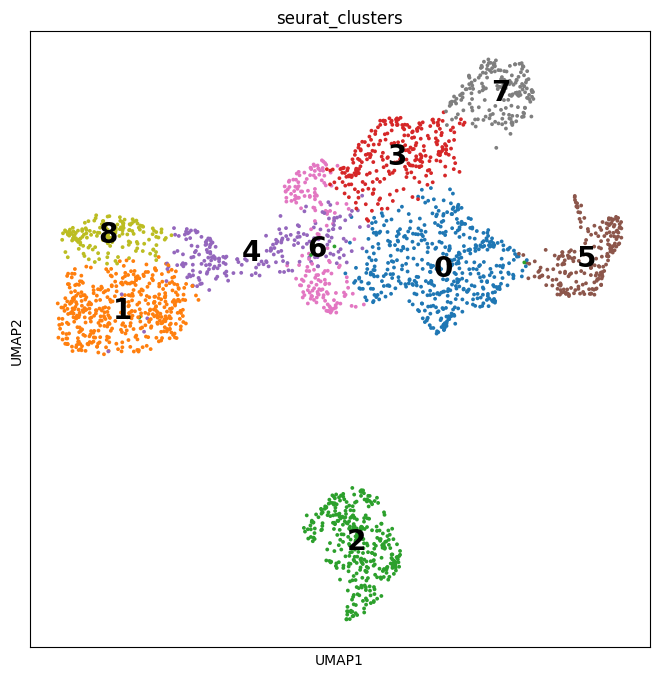

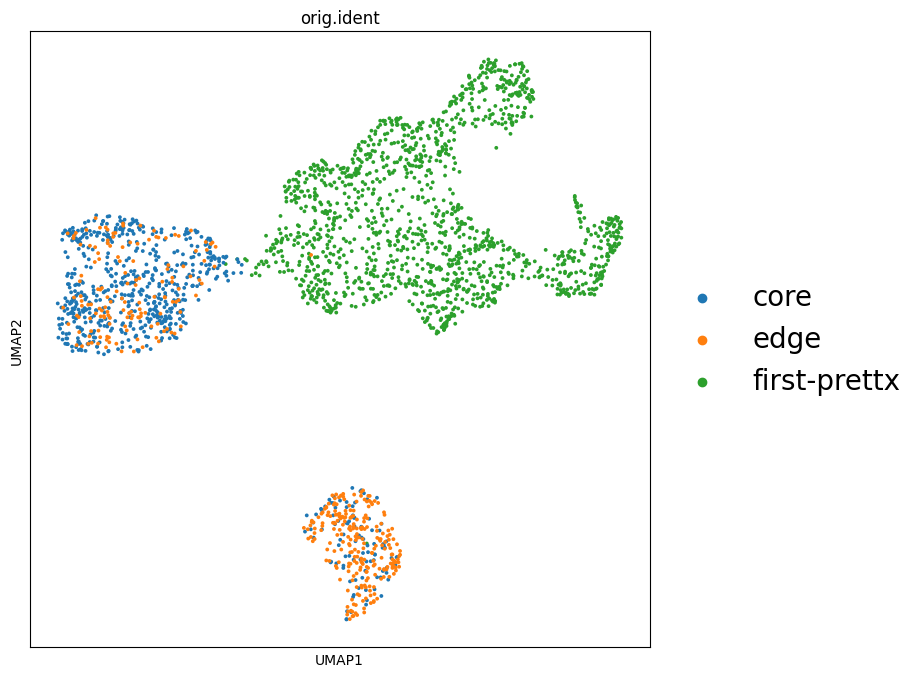

In [4]:
# show regions in UMAP coordinates
with mpl.rc_context({'axes.facecolor':  'white',
                     'figure.figsize': [8, 8]}):
    sc.pl.umap(adata, color=['seurat_clusters'], size=30,
               color_map = 'RdPu', ncols = 2, legend_loc='on data',
               legend_fontsize=20)
    # sc.pl.umap(adata, color=['ClusterName'], size=30,
    #            color_map = 'RdPu', ncols = 2,
    #            legend_fontsize=20)
    sc.pl.umap(adata, color=['orig.ident'], size=30,
               color_map = 'RdPu', ncols = 2,
               legend_fontsize=20)

In [5]:
sc.pp.neighbors(adata)

/home/cruiz2/miniconda3/envs/r_env_standr/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
sc.tl.paga(adata, groups="seurat_clusters")

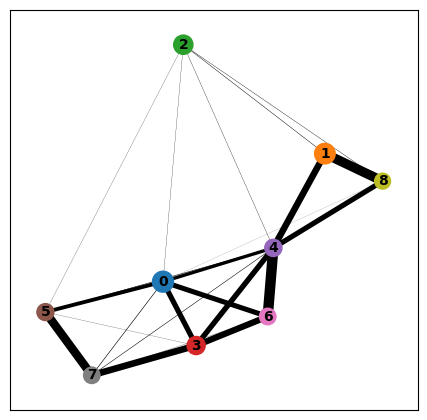

In [7]:
sc.pl.paga(adata, color='seurat_clusters')

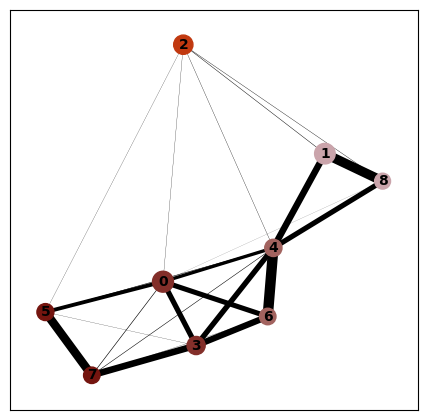

In [14]:
custom_palette = ['#832f2a', '#caa4ab', '#c13910', '#832f2a', 
                  '#a2635f', '#74150f', '#a2635f', '#74150f', '#caa4ab']

if 'seurat_clusters' in adata.obs:
    if not adata.obs['seurat_clusters'].dtype.name == 'category':
        adata.obs['seurat_clusters'] = adata.obs['seurat_clusters'].astype('category')

    adata.uns['seurat_clusters_colors'] = custom_palette

sc.pl.paga(adata, color='seurat_clusters', save='figures/paga_primary_tumor_ascites.pdf')

In [15]:
import palantir

# warnings
import warnings
from numba.core.errors import NumbaDeprecationWarning

warnings.filterwarnings(action="ignore", category=NumbaDeprecationWarning)
warnings.filterwarnings(
    action="ignore", module="scanpy", message="No data for colormapping"
)

In [16]:
adata = adata[adata.obs['seurat_clusters'] != '2']
adata

View of AnnData object with n_obs × n_vars = 2136 × 17005
    obs: 'orig.ident', 'nCount_RNA', 'RNA_snn_res.0.7', 'seurat_clusters', 'cellcycle1', 'OC2', 'AC3', 'OPC_shared4', 'OPC_variable5'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    uns: 'seurat_clusters_colors', 'orig.ident_colors', 'neighbors', 'paga', 'seurat_clusters_sizes'
    obsm: 'X_mnn', 'X_pca', 'X_umap'
    obsp: 'distances', 'connectivities'

In [17]:
dm_res = palantir.utils.run_diffusion_maps(adata, n_components=5)

/home/cruiz2/miniconda3/envs/r_env_standr/lib/python3.9/site-packages/palantir/utils.py:482: ImplicitModificationWarning: Setting element `.obsp['DM_Kernel']` of view, initializing view as actual.
  data.obsp[kernel_key] = res["kernel"]


In [18]:
ms_data = palantir.utils.determine_multiscale_space(adata)

In [19]:
imputed_X = palantir.utils.run_magic_imputation(adata)

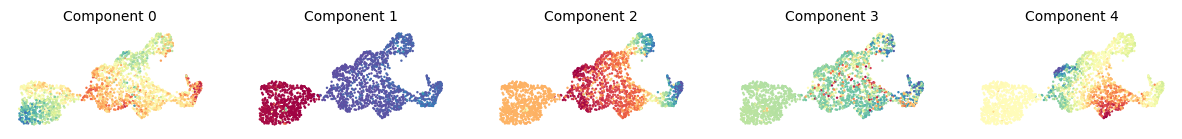

In [20]:
palantir.plot.plot_diffusion_components(adata)
plt.show()

In [21]:
# Assuming 'adata' is your AnnData object
# List of clusters to sample from
clusters_of_interest = ['7','5','1']

# Initialize an empty dictionary to store results
random_obs_names = {}

# Iterate through each cluster and select a random observation name
for cluster in clusters_of_interest:
    # Subset the AnnData object for the current cluster
    cluster_cells = adata.obs[adata.obs['seurat_clusters'] == cluster]
    
    # Randomly select one obs_name
    if not cluster_cells.empty:
        random_obs_name = np.random.choice(cluster_cells.index, size=1, replace=False)[0]
        random_obs_names[cluster] = random_obs_name
    else:
        random_obs_names[cluster] = None  # Handle cases where no cells exist for the cluster

# Print or return the dictionary of random obs_names
print(random_obs_names)

{'7': 'ascites_first-prettx_GTTAGTGTCTCTCTTC-1', '5': 'ascites_first-prettx_GAGGCAATCCATTTGT-1', '1': 'primary.tumor_core_CATCCACAGGAAGAAC-1'}


In [22]:
terminal_states = pd.Series(
    ["CloneA", "CloneB"],
    index=["ascites_first-prettx_TTGAGTGGTTAGTCGT-1", "ascites_first-prettx_AGGACTTTCTGTGCTC-1"],
)

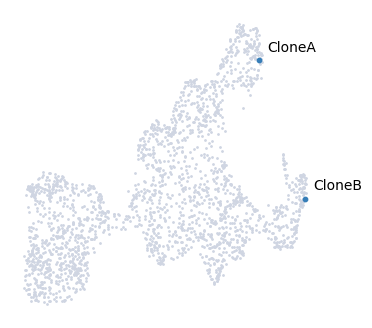

In [23]:
palantir.plot.highlight_cells_on_umap(adata, terminal_states)
plt.show()

In [24]:
start_cell = "primary.tumor_edge_GATAGAAGTAATTAGG-1"
pr_res = palantir.core.run_palantir(
    adata, start_cell, num_waypoints=500, terminal_states=terminal_states
)

Sampling and flocking waypoints...
Time for determining waypoints: 0.0022921085357666014 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.08944244782129923 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


In [26]:
masks = palantir.presults.select_branch_cells(adata, q=.01, eps=.01)

In [27]:
gene_trends = palantir.presults.compute_gene_trends(
    adata,
    expression_key="MAGIC_imputed_data",
)

CloneB
[2025-01-09 03:56:07,811] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (1,935) and rank = 1.0.
[2025-01-09 03:56:07,812] [INFO    ] Using covariance function Matern52(ls=1.0).
CloneA
[2025-01-09 03:56:09,767] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (2,007) and rank = 1.0.
[2025-01-09 03:56:09,768] [INFO    ] Using covariance function Matern52(ls=1.0).


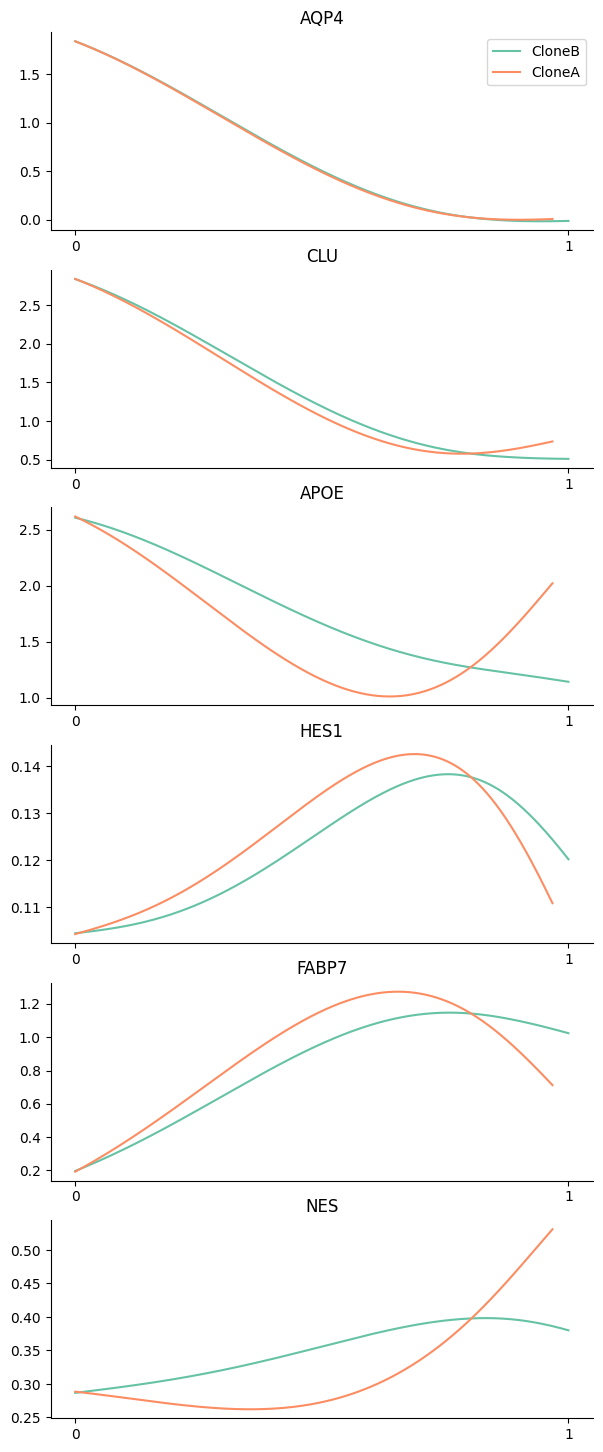

In [38]:
genes = ["AQP4", "CLU","APOE","HES1","FABP7", 'NES']
palantir.plot.plot_gene_trends(adata, genes)
plt.show()

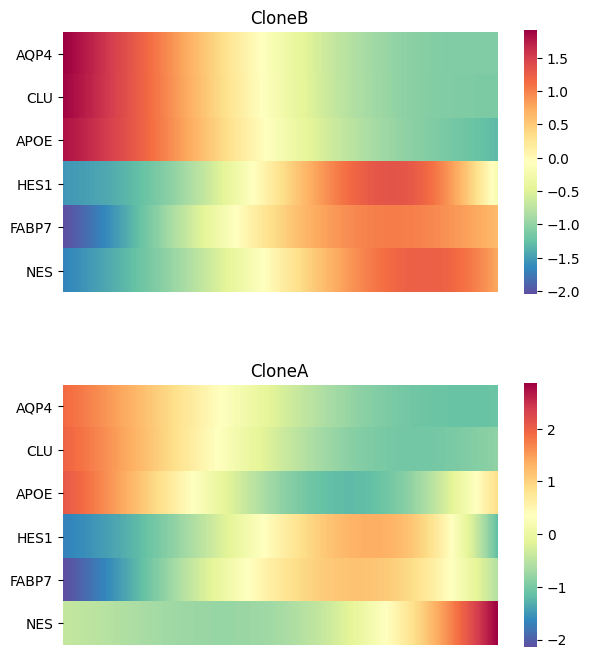

In [40]:
palantir.plot.plot_gene_trend_heatmaps(adata, genes)
plt.savefig('figures/gene_trends_ac_rg.pdf')
plt.show()